# Sentralitet

Noen noder er alltid mer sentrale enn andre.  Det er mange måter å "definere" det å være sentral, og alle har fordeler (og ulemper).
De sentrale (_no pun intended_) er 
- Populære noder (_degree centrality_)
- Bronoder (_betweenness centrality_)
- Sentrale noder (_closeness centrality_)
- Viktige noder (_eigenvektor_ eller _page rank_)

Vi skal se på alle fire

## Hente inn to grafer som eksempler

### Epost-grafen

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [2]:

import gzip

EG = nx.DiGraph()
# husk at gzip påpner i 'b'
with gzip.open("data/email.edgelist.txt.gz", "rt") as fd:
    for linje in fd:
         link = linje.split()
         EG.add_edge(int(link[0]), int(link[1]))
    #
#
print(f"Antall noder i grafen: {EG.number_of_nodes()}")
print(f"Antall kanter i grafen: {EG.number_of_edges()} (antall eposter)")
# Bort med eposter sendt til seg selv
EG.remove_edges_from(nx.selfloop_edges(EG))
print(f"Antall kanter etter selv-loop: {EG.number_of_edges()}")
# Og noder uten linker til seg nå
isolerte = list(nx.isolates(EG)) # kan ikke bruke iteratorer direkte
EG.remove_nodes_from(isolerte)
print(f"Antall noder etter isolerte: {EG.number_of_nodes()}")
# ANtall kanter i hver node
antall = []
for node, naboer in EG.degree():
    antall += [naboer]
    # eller antall = [d for n, d in EG.degree()]
#
print(f"Funnet Stdev:   {np.std(antall):.4f}")
print(f"Funnet Median:   {np.mean(antall):.4f}")

Antall noder i grafen: 57194
Antall kanter i grafen: 103731 (antall eposter)
Antall kanter etter selv-loop: 103083
Antall noder etter isolerte: 57189
Funnet Stdev:   36.0183
Funnet Median:   3.6050


lite sammenheng mellom median og standardavviket.
La oss se på noen tilfeldige noder:

In [3]:
# Dette er jo litt usikkert -- la oss håpe nodene vi finner understreker 
# poenget, nemlig at de IKKE har mange kanter
import random

for i in range(10):
    node = int(random.random() * EG.number_of_nodes())
    print(f"Node {node}: inn {len(EG.in_edges(node))} ut {len(EG.out_edges(node))}")

Node 15074: inn 1 ut 1
Node 17648: inn 1 ut 2
Node 23643: inn 0 ut 1
Node 33950: inn 1 ut 0
Node 9435: inn 1 ut 0
Node 36854: inn 1 ut 1
Node 22854: inn 0 ut 1
Node 33701: inn 1 ut 2
Node 39581: inn 0 ut 1
Node 56342: inn 0 ut 1


Men la oss se på noen utvalgte noder

In [4]:
print(f"63    ut: {len(EG.out_edges(63))}  in: {len(EG.in_edges(63))}")
print(f"40    ut: {len(EG.out_edges(40))}   in: {len(EG.in_edges(40))}")
print(f"407   ut: {len(EG.out_edges(407))}   in: {len(EG.in_edges(407))}")
print(f"1704  ut: {len(EG.out_edges(1704))}  in: {len(EG.in_edges(1704))}")
print(f"11798 ut: {len(EG.out_edges(11798))} in: {len(EG.in_edges(11798))}")
print(f"11028 ut: {len(EG.out_edges(11028))} in: {len(EG.in_edges(11028))}")
print(f"32199 ut: {len(EG.out_edges(32199))} in: {len(EG.in_edges(32199))}")

63    ut: 13  in: 29
40    ut: 0   in: 274
407   ut: 0   in: 205
1704  ut: 51  in: 107
11798 ut: 881 in: 262
11028 ut: 4170 in: 8
32199 ut: 6553 in: 2


### Les Misérables

In [9]:
# La oss bruke den innebygde
MG = nx.les_miserables_graph()

antall = []
for node, naboer in MG.degree():
    antall += [naboer]
    # eller antall = [d for n, d in EG.degree()]
#
print(f"Funnet Stdev:   {np.std(antall):.4f}")
print(f"Funnet Median:   {np.mean(antall):.4f}")

Funnet Stdev:   6.0006
Funnet Median:   6.5974


## Fire typer sentralitet


|Type|Hva som måles|Idé|Observasjon|
|---|---|---|---|
|Popularitet|Antall kanter|Hvor mange venner har du|Tar ikke hensyn til "kvaliteten" på vennene dine|
|Bronoder|Antall korteste (andres)<br>sti gjennom noden|Knytter sammen samfunnet,<br>mye informasjon flyter forbi|Du kan være en bro uten å være viktig selv|
|Sentrale|Antall korteste sti til andre noder|Nær der ting skjer|Følsom for endringer - tung å beregne|
|Viktig|Aggregert viktighet av naboene|Er viktig ved å kjenne mange viktige|Må iterere over hele grafen|



## Populære noder
Dette er det enkleste: Antall linker (til andre noder).  Kjører i $O(N)$ som en følge av at man må traversere alle noder (og vi husker at fordi sortering "bare" er $O(\log N)$ er totalen $O(N)$ og ikke $O(N) + O(N \log N)$).

Sier ikke så mye om hvorvidt noden er relevant eller ei.  Kan godt være at jeg kjenner flere i PIT enn Direktøren, men de hun kjenner er viktigere.

In [6]:
# Tar mindre enn ett sekund
populæritet = nx.degree_centrality(EG)
top_populære_noder = sorted(populæritet, key=populæritet.get, reverse=True)[:5]
print("5 mest populære:")
for n in top_populære_noder:
    print(f"\t Node: {n} Naboer: {EG.degree[n]}")
#

5 mest populære:
	 Node: 32199 Naboer: 6555
	 Node: 11028 Naboer: 4178
	 Node: 13678 Naboer: 1228
	 Node: 11798 Naboer: 1143
	 Node: 13498 Naboer: 809


Legg merke til at det her telles naboer uten å ta hensyn til retningen.

## Bronoder
En bro som knytter en øy til fastlandet, den er viktig fordi alle må over den.  Broen har bare to kanter til seg (én på hver side) og ikke populær (se over), og broen behøver ikke være nær noe viktig (sentrum av byen) men **posisjonen** relativt til andre noder i grafen gjør den viktig.  En bronode beskriver en strukturell plassering, heller enn egenskaper ved noden selv.

Teknisk er broen på korteste sti mellom mange andre (uansett hvem du skal besøke må du over broen).

Det følger av posisjonen at om en bronode feiler deles grafen.  Man finner bronoder ved å se hva som skjer når noder fjernes; de nodene som fører til at grafen separeres, de er bronoder.  Med andre ord: Ved å fjerne (fengsle?) bronoder fragmenterer man grafen.

Å finne bronoder krever å finne korteste sti for alle noder.  Raskeste algoritme er [Brande's algoritme](https://en.wikipedia.org/wiki/Brandes%27_algorithm) som kjører i $O(VE)$ tid.  Det betyr at kompleksiteten stiger lineært både med hvor "tett" den er og hvor "stor" den er.

Fordi bronoder står mellom grupper av andre norder er den engelske termen _betweenness_.

In [7]:
import time

start = time.time()
broer = nx.betweenness_centrality(MG)
top_bronoder = sorted(broer, key=broer.get, reverse=True)[:5]
print("5 viktigste bronoder")
for n in top_bronoder:
    print(f"\t Node: {n} Naboer: {MG.degree[n]}")
#
print(f"Å finne bronoder tok {time.time()-start:.2f} sekunder")


5 viktigste bronoder
	 Node: Valjean Naboer: 36
	 Node: Myriel Naboer: 10
	 Node: Gavroche Naboer: 22
	 Node: Marius Naboer: 19
	 Node: Fantine Naboer: 15
Å finne bronoder tok 0.02 sekunder


I en rettet graf må man være nøye med å definere hva en deling av grafen betyr (og derfor hva en bronode er).  Særlig: En node kan forbinde to deler i én retning men ikke den andre.

Legg merke til at vi ikke bruker epost-grafen som eksempel.  Å kjøre på epost-grafen tar tre kvarter, og resultatene er:

5 viktigste bronoder
-         Node: 11798 Naboer: 1143
-         Node: 1189 Naboer: 121
-         Node: 32199 Naboer: 6555
-         Node: 11028 Naboer: 4178
-         Node: 13498 Naboer: 809
Å finne bronoder tok 2873.13 sekunder

For Miserables kan vi tegne bronodene:

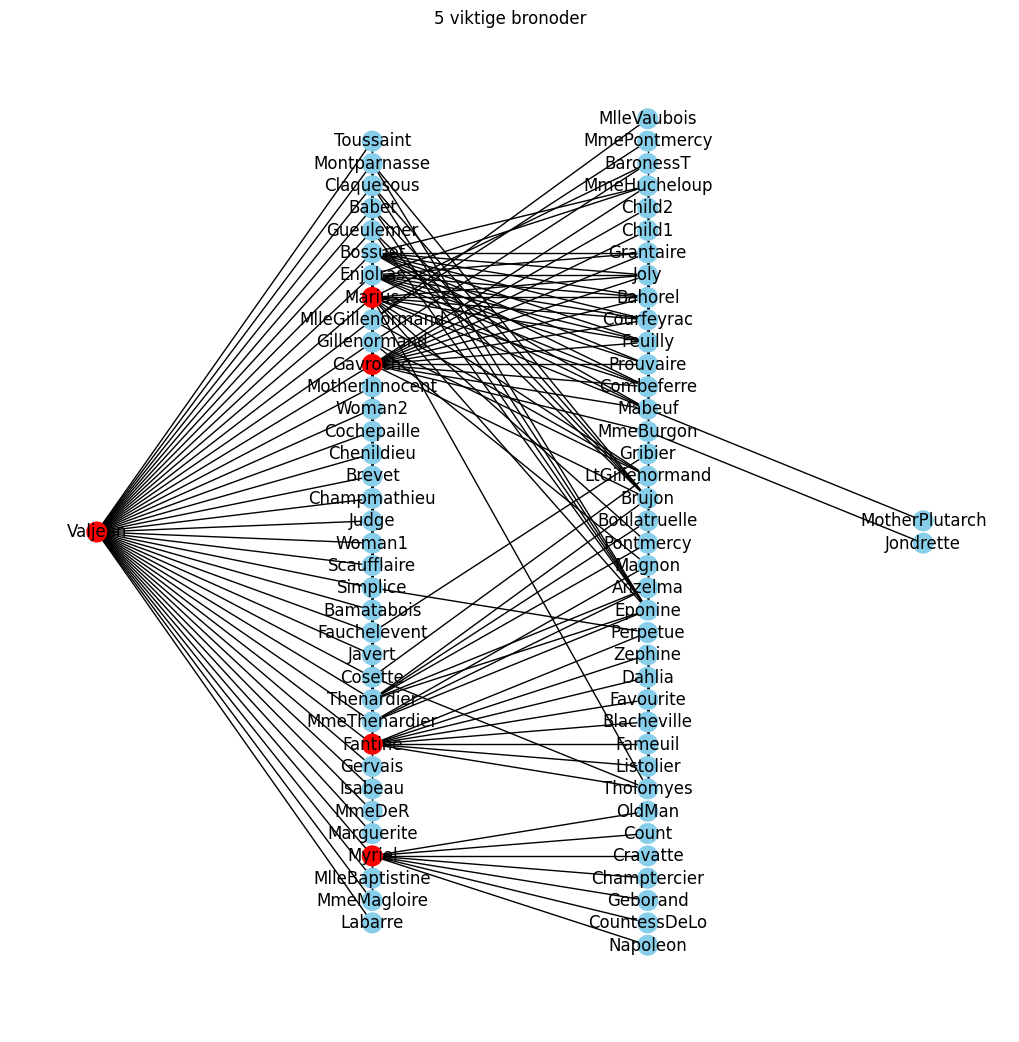

In [10]:
plt.figure(figsize=(10, 10))
top_bronoder = sorted(broer, key=broer.get, reverse=True)[:5]
node_farge = []
for n in MG.nodes():
    if n in top_bronoder:
        node_farge += ["red"]
    else:
        node_farge += ["skyblue"]
    #
# Eller om du vil lese fra høyre mot venstre: ['red' if node in top_bronoder else 'skyblue' for node in MG.nodes()]
pos = nx.bfs_layout(MG, start="Valjean")  # Layout og startnode
nx.draw(MG, pos, with_labels=True, node_color=node_farge, node_size=200)
plt.title("5 viktige bronoder")
plt.show()

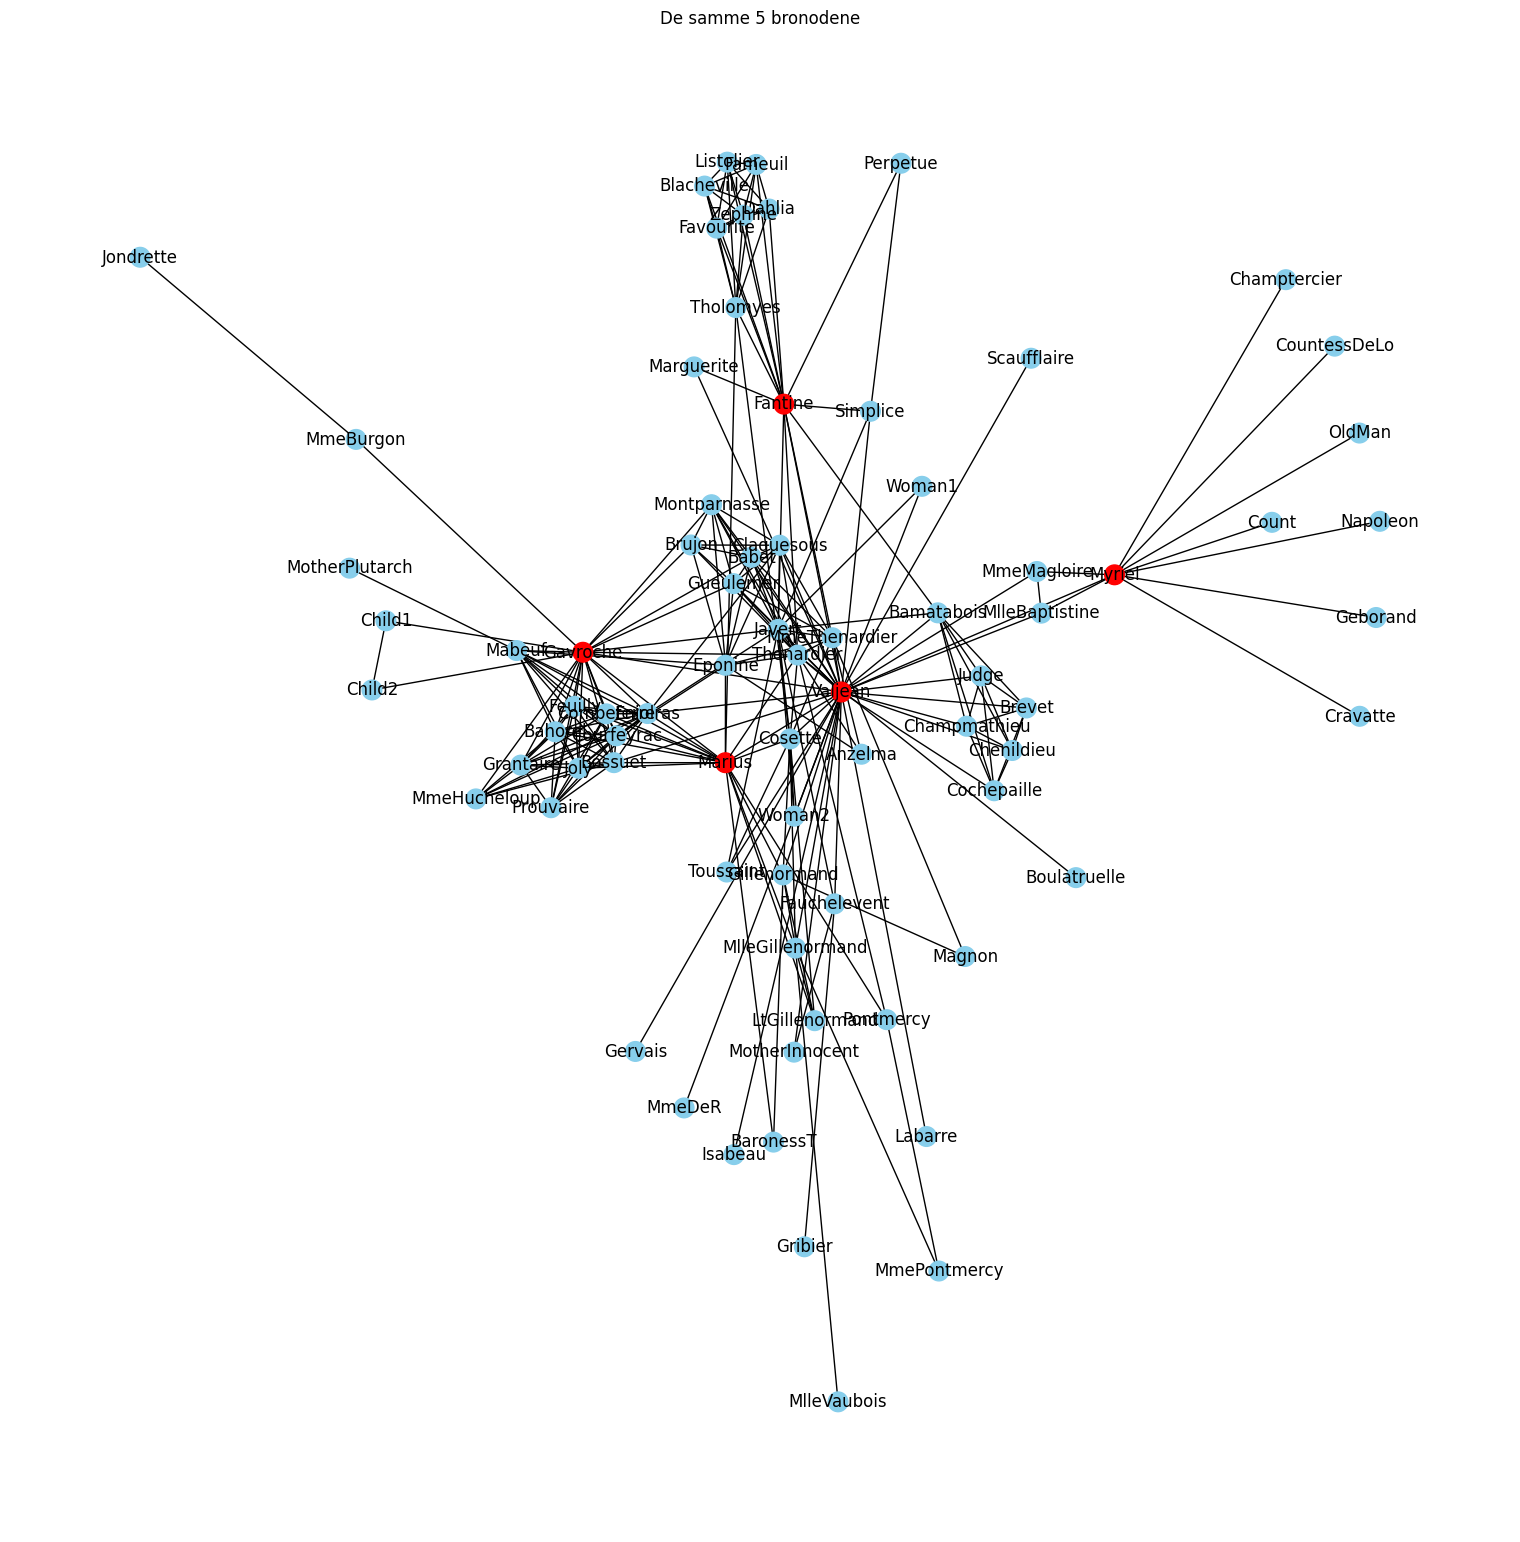

In [11]:
plt.figure(figsize=(15, 15))
pos = nx.spring_layout(MG)
nx.draw(MG, pos, with_labels=True, node_color=node_farge, node_size=200)
plt.title("De samme 5 bronodene")
plt.show()

## Sentrale noder
Hvor tilgjengelig noden er for andre (lav gjennomsnitt korteste sti til andre noder).  Direktøren i PIT er trolig mest sentral i organisasjonen, som en følge av at hun har kortere vei "ned" til alle ansatte enn noen andre.

Sentrale noder har kort vei til andre, og vil derfor høre rykter hurtig.  Og, vice versa, kunne spre rykter og nyheter raskt.

Kompleksiteten aqvhenger ikke så mye av om grafen er rettet eller ei ($O(E+N)$ mot $O(E+N \log N$) for hver node, hvor $N$ er antall noder) men en rettet graf vil naturligvis ha "færre" kanten (fordi kanter i "andre retningen" ikke teller).  Videre kan en rettet graf være delt i betydningen av at én node kan nå til en annen, men ikke motsatt.

Om vi antar at kantene hverken har retning eller vekt, og har relativt få kanten (i forhold til maksimalt antall) da bruker vi bredde-først og kompleksiteten er $O(N^2)$. Om antall kanter er høyt nærmer kompleksiteten seg $O(N^3$) .  Det skal ikke så mye til før det er ønskelig med tilnærminger heller enn eksakte løsninger.

Det er en likhet mellom bronoder og sentrale noder.

Fordi kort vei til andre er essensen, heter dise nodene _closeness_ på engelsk.

In [12]:
import time

start = time.time()
UG = MG.to_undirected(MG) # Miserables-grafen
sentrale = nx.closeness_centrality(UG)
top_sentrale = sorted(sentrale, key=sentrale.get, reverse=True)[:5]
print("5 mest sentrale noder:")
for n in top_sentrale:
    print(f"\t Node: {n} Naboer: {UG.degree[n]}")
#   
print(f"Å finne sentrale noder {time.time()-start:.2f} sekunder")

5 mest sentrale noder:
	 Node: Valjean Naboer: 36
	 Node: Marius Naboer: 19
	 Node: Thenardier Naboer: 16
	 Node: Javert Naboer: 17
	 Node: Gavroche Naboer: 22
Å finne sentrale noder 0.01 sekunder


Det tok en halv time å kjøre på epost-grafen:

5 mest sentrale noder:
-          Node: 11028 Naboer: 4171
-          Node: 32199 Naboer: 6553
-          Node: 11798 Naboer: 1018
-          Node: 13498 Naboer: 802
-          Node: 12586 Naboer: 289
Å finne sentrale noder tok 1771.29 sekunder

## Viktige noder
Om vi myser litt, ser vi at populære, sentrale, og bronoder alle har sine egenskaper som en følge av sin plassering i grafen.  Altså ingen andre egenskaper enn posisjonen (lokasjonen).  I særdeleshet: det er ingen semantikk knyttet til rangeringene (bare "fysisk plassering").

Den mest kjente og brukte er *eigenvector centrality*.  For å si det forsiktig har Google gjort denne kjent under navnet **page rank**.  Essensen er at det er viktigere å ha viktige venner, enn mange venner.  Dersom mange sender epost til deg, da er du viktig.  De du sender epost til, blir viktige fordi du gjør det.  

I kontekst av en rettet graf kan vi tenke på det som en funksjon av hvor mange innkommende linker det er til en node (relativt til antall linker totalt), hvem de linkene kommer fra, og hvor mange utgående linker du har.  Jo flere utgående linker du har, jo flere "sprer" du din innflytese til og hvert av dine bidrag blir mindre.  

Om vi tenker på WWW så er det de sidene som mange linker til som er viktige, og sidene de viktige linker til, blir også viktige.  Om The New Times linker til din hjemmeside så blir din side interessant for mange.

Å finne hvem som er viktige er en iterativ prosess.  All "viktighet" fordeles likt over alle noder ($1/N$ på hver node).  For hver iterasjon fordeles hver nodes viktighet på alle noder den linker til.  Effekten blir at de nodene som har mange innkommende linker mottar mye, og alt de har fordeles til de nodene de linker til.  Etter "noen" iterasjoner vil situasjonen stabilisere seg.  Iterasjonen begrenses altså av hva man definerer som stabilt.

En annen ekvivalent modell er å ha en "tilfeldig" surfer.  For hver node velges tilfeldig én av de utgående kantene.  Fra "tid til annen" velges et nytt startsted.  For hver iterasjon noteres det hvor surferen er.  Over tid vil antall ganger en node er besøkt representere hvor viktig noden er, eller med andre orde: Hva er sannsynligheten for at en node blir besøk.  Resultatet blir det samme som den andre itertive prosessen.  Fordi surferen alltid vil være ett (1) sted, må sannsynligheten summert over nodene være 1.  Det betyr at summen av viktigheten over alle noder også vil være 1.<br>
I margen noterer vi at Neo4J starter beregningen ved å sette viktigheten i alle noder til 1 (og ikke $1/N$).  Det betyr at summen av viktigheten over alle noder blir $N$; enkelt å normalisere ved behov.


### Eigenvektor
Resultatet ("page rank" for alle noder) kan betraktes som vektor $x$ som er $N$ elementer lang.   Fordi $x$ representerer en stabil egenskap i betydningen av at om man skalerer alle verdiene, blir relasjonene mellom dem uendret.  Det betyr også at om vi setter opp nodene som en todimensjonal matrise $A$ hvor et element $(n,m)$ er satt om det er en link fra $n$ til $m$, da vil $Ax = \lambda x$.  Det betyr at $x$ er en **eigenvektor** i $A$.

Betraktningen om at viktigheten representerer en stabil egenskap i grafen hviler på en del forutsetninger, med tilhørende diskusjoner.  For eksempel fjernet vi _self loops_ da vi lastet inn grafen.  Når det er snakk om relasjoner mellom mennesker, da er det kanskje (!) relevant å vurdere å se bort fra retningen på kantene.  

Vi burde kanskje arrangere et seminar om _page rank_.

Kompleksiteten for å finne viktige noder er "bare" $O(V+E)$.

In [13]:
# Beregne de viktigste nodene i MG
import time

start = time.time()
page_rank = nx.eigenvector_centrality(MG)
viktigste_noder = sorted(page_rank, key=page_rank.get, reverse=True)[:5]
print("5 viktigste i Miserables:")
for n in viktigste_noder:
    print(f"\t Node {n}  har {MG.degree[n]} naboer")
#   
print(f"Å finne viktige noder {time.time()-start:.2f} sekunder")

5 viktigste i Miserables:
	 Node Gavroche  har 22 naboer
	 Node Valjean  har 36 naboer
	 Node Enjolras  har 15 naboer
	 Node Marius  har 19 naboer
	 Node Bossuet  har 13 naboer
Å finne viktige noder 0.00 sekunder


In [14]:
# Beregne de viktigste nodene i EG
import time

start = time.time()
page_rank = nx.eigenvector_centrality(EG)
viktigste_noder = sorted(page_rank, key=page_rank.get, reverse=True)[:5]
print("5 viktigste i epost:")
for n in viktigste_noder:
    print(f"\t Node {n}  har {EG.degree[n]} naboer")
#   
print(f"Å finne viktige noder {time.time()-start:.2f} sekunder")

5 viktigste i epost:
	 Node 11798  har 1143 naboer
	 Node 12586  har 333 naboer
	 Node 14603  har 297 naboer
	 Node 288  har 108 naboer
	 Node 33  har 112 naboer
Å finne viktige noder 1.16 sekunder


Vi kan se på de viktige hos Miserables:


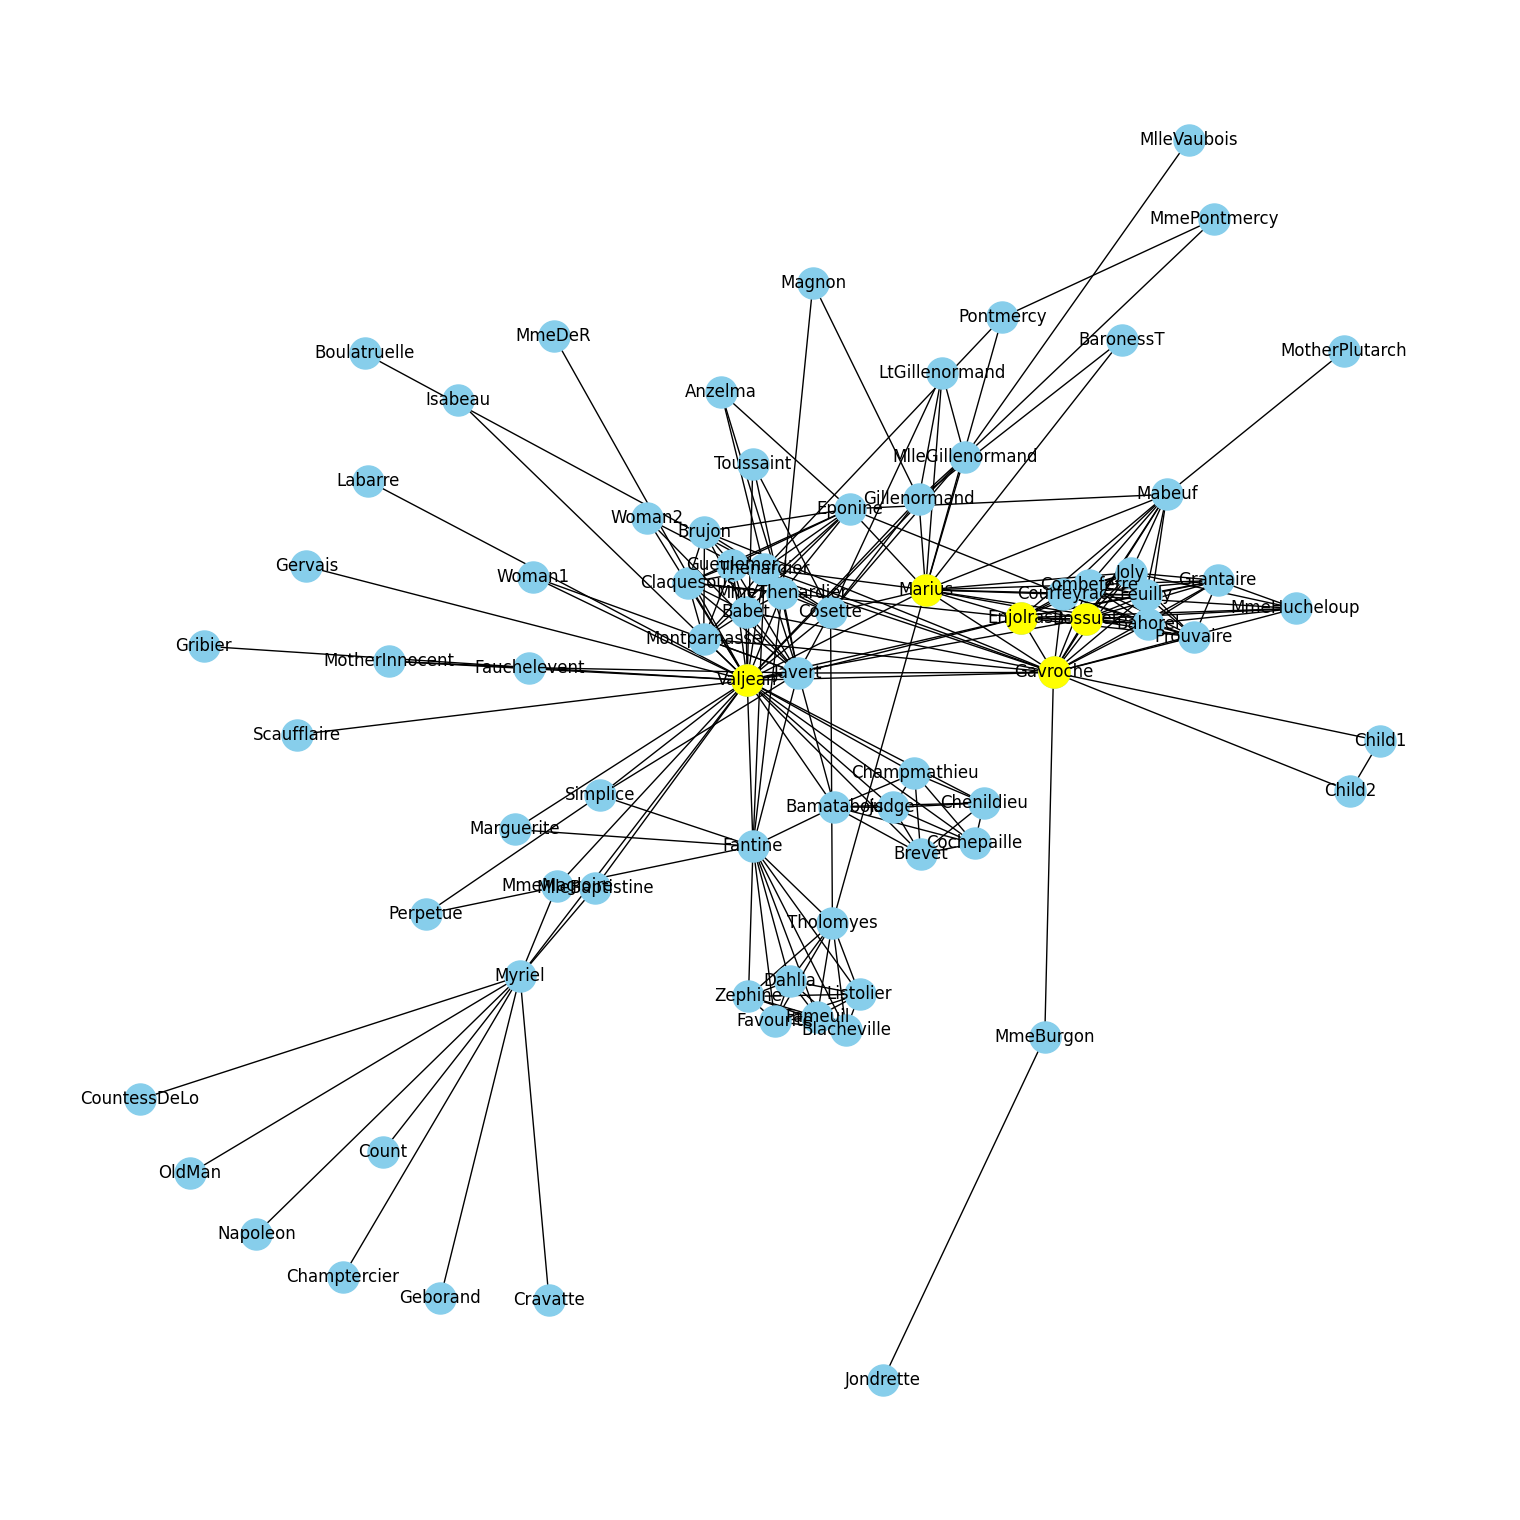

In [15]:
# Beregne de viktigste nodene
page_rank = nx.eigenvector_centrality(MG)
viktigste_noder = sorted(page_rank, key=page_rank.get, reverse=True)[:5]

# Få se
plt.figure(figsize=(15, 15))
pos = nx.spring_layout(MG)
nx.draw(MG, pos, with_labels=True, node_color='skyblue', font_size=12, node_size=500)

# Gi de viktige en annen farge
nx.draw_networkx_nodes(MG, pos, nodelist=viktigste_noder, node_color='yellow', node_size=500)
plt.show()

Antall noder i epost er så stort at det er svært vanskelig å vise dem frem.  Vi gjør et forsøk i en annen *notebook*.

## Konklusjon

Det kan synes naturlig å starte jakten på "bakmenn" ved å lete etter sentrale personer.  At det ikke finnes én definisjon av sentral illsutrerer problemet.

Jeg tror denne teknologien krever helt ekstraordinære mengder domenekunnskap!